In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict
import torch

In [ ]:
from PIL import Image
import numpy as np
from collections import Counter

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = '/content/drive/MyDrive/sort_model/garbage-dataset'

In [ ]:
# list all class folders
classes = sorted(os.listdir(dataset_path))
print(f"Found {len(classes)} classes:")
print(classes)

Found 10 classes:
['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [ ]:
# count number of images per class
class_counts = {}
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    images = os.listdir(cls_path)
    class_counts[cls] = len(images)

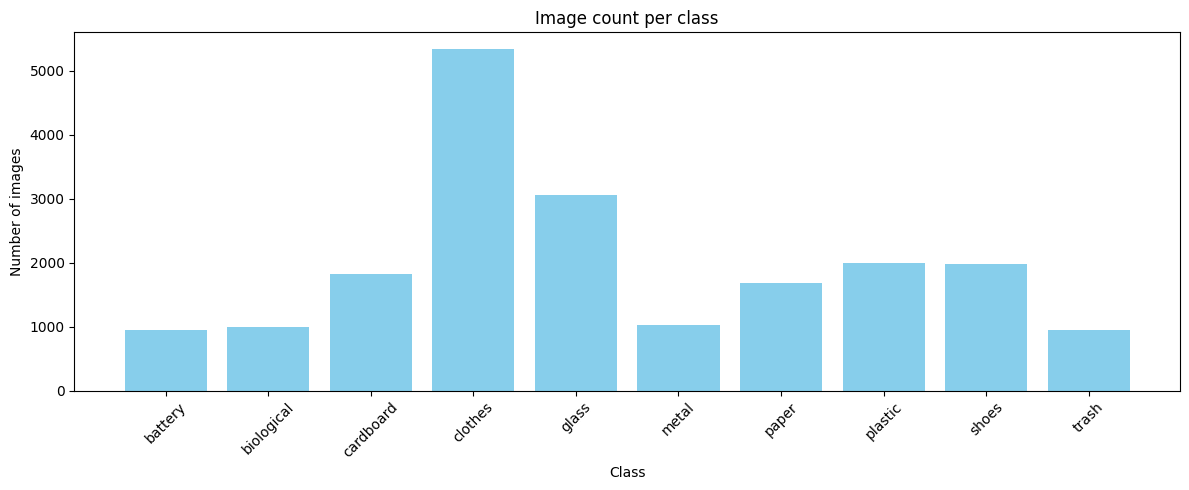

In [ ]:
# plot class distribution
plt.figure(figsize=(12, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.title("Image count per class")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
class_counts

{'battery': 944,
 'biological': 997,
 'cardboard': 1825,
 'clothes': 5337,
 'glass': 3061,
 'metal': 1020,
 'paper': 1680,
 'plastic': 1994,
 'shoes': 1977,
 'trash': 947}

In [ ]:
image_shapes = []
image_modes = []
image_formats = []

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    image_files = os.listdir(cls_path)
    for fname in image_files[:200]:  # limit to first 200 per class to save time
        fpath = os.path.join(cls_path, fname)
        try:
            with Image.open(fpath) as img:
                image_shapes.append(img.size)      # (width, height)
                image_modes.append(img.mode)       # e.g., RGB or L
                image_formats.append(img.format)   # e.g., JPEG, PNG
        except Exception as e:
            print(f"Failed to load {fpath}: {e}")

# check most common sizes
print("Most common image sizes:")
print(Counter(image_shapes).most_common(5))

# check color modes
print("\nImage modes (color channels):")
print(Counter(image_modes))

# check formats
print("\nImage formats:")
print(Counter(image_formats))

Most common image sizes:
[((512, 384), 292), ((225, 225), 245), ((275, 183), 101), ((400, 533), 92), ((259, 194), 85)]

Image modes (color channels):
Counter({'RGB': 1896, 'RGBA': 100, 'P': 4})

Image formats:
Counter({'JPEG': 1895, 'PNG': 105})


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# base dataset path
DATASET_PATH = '/content/drive/MyDrive/sort_model/garbage-dataset'

# image size we'll use throughout the project
IMAGE_SIZE = 224  # standard for CNN models like ResNet/MobileNet

# training parameters
BATCH_SIZE = 32
SEED = 42

In [ ]:
# transformation for training: resize + data augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# transformation for validation/test: only resize + normalize
test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


In [ ]:
# load full dataset with training transforms (we'll split it manually)
full_dataset = datasets.ImageFolder(root=DATASET_PATH, transform=train_transforms)


In [ ]:
# define split sizes
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

# fix random seed for reproducibility
generator = torch.Generator().manual_seed(SEED)

# split dataset
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size], generator=generator)

# use correct transform for val/test sets
val_dataset.dataset.transform = test_transforms
test_dataset.dataset.transform = test_transforms


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [ ]:
# show number of samples
print(f"train: {len(train_dataset)} images")
print(f"val: {len(val_dataset)} images")
print(f"test: {len(test_dataset)} images")

# check number of classes
print(f"classes: {full_dataset.classes}")


train: 13847 images
val: 2967 images
test: 2968 images
classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [ ]:
images, labels = next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([32, 3, 224, 224]) torch.Size([32])
